## EDA & Diagnostics

Goals:
1. Distribution of target → decide on transform
2. Identify collinearity *before* modeling
3. Pearson + Spearman correlation views
4. Panel structure: within vs between variance, time dynamics
5. Systematic VIF
6. Outlier / leverage check

### A.0 Setup

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

from pathlib import Path

# Plot config — readable, consistent
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
})
sns.set_style('whitegrid')

# Path: notebook expects dataset in same dir or project /data dir
DATA_PATH = Path('../data/raw_data/dmv_rent_income_dataset.csv')


### A.1 Load & initial inspection

In [8]:
df = pd.read_csv(DATA_PATH)
df['zip'] = df['zip'].astype(str).str.zfill(5)

print(f'Shape: {df.shape}')
print(f'ZIPs: {df["zip"].nunique()}, Years: {(df["year"].unique())}')

Shape: (840, 16)
ZIPs: 168, Years: [2018 2019 2020 2021 2022]


In [ ]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
year,840.0,2020.000,1.415,2018.000,2019.000,2020.000,2021.000,2022.000
median_income,840.0,112976.592,36777.183,32286.000,86588.750,108636.000,133226.750,250001.000
median_rent,840.0,1823.895,380.855,828.000,1585.500,1805.500,2041.000,3320.000
rent_to_income,840.0,0.205,0.053,0.097,0.174,0.201,0.226,0.663
pct_renter,840.0,0.381,0.192,0.057,0.222,0.346,0.533,0.934
poverty_rate,840.0,0.082,0.055,0.007,0.043,0.071,0.101,0.424
pct_bachelors_plus,840.0,0.374,0.158,0.086,0.253,0.349,0.482,0.882
pct_white,840.0,0.451,0.225,0.010,0.282,0.474,0.631,0.862
pct_black,840.0,0.235,0.231,0.015,0.074,0.138,0.290,0.945
pct_asian,840.0,0.105,0.087,0.001,0.034,0.082,0.148,0.398


### A.2 Structural variable diagnostics

Before any model, identify variables that are **mechanically collinear** (sums-to-one constraints from compositional data).

In [10]:
# Check 1: sex variables sum to 1?
sex_sum = df['pct_male'] + df['pct_female']
print('pct_male + pct_female:')
print(f'min={sex_sum.min():.6f}, max={sex_sum.max():.6f}')


# Check 2: race + Hispanic
race_sum = df[['pct_white','pct_black','pct_asian','pct_hispanic']].sum(axis=1)
print('pct_white + pct_black + pct_asian + pct_hispanic:')
print(f'  mean={race_sum.mean():.3f}, min={race_sum.min():.3f}, max={race_sum.max():.3f}')


pct_male + pct_female:
min=1.000000, max=1.000000
pct_white + pct_black + pct_asian + pct_hispanic:
  mean=0.956, min=0.879, max=0.994


**Decision rules from A.2**

| Variable group | Action |
|---|---|
| Gender | Drop `pct_female` (perfect collinearity) |
| Race | Keep all 4 → check VIF |

### A.3 Target distribution & range transform

`rent_to_income` is **bounded in [0, 1]** (technically; can exceed 1 for severe burden). OLS assumes unbounded error — need to check skewness, normality, and whether transform helps.

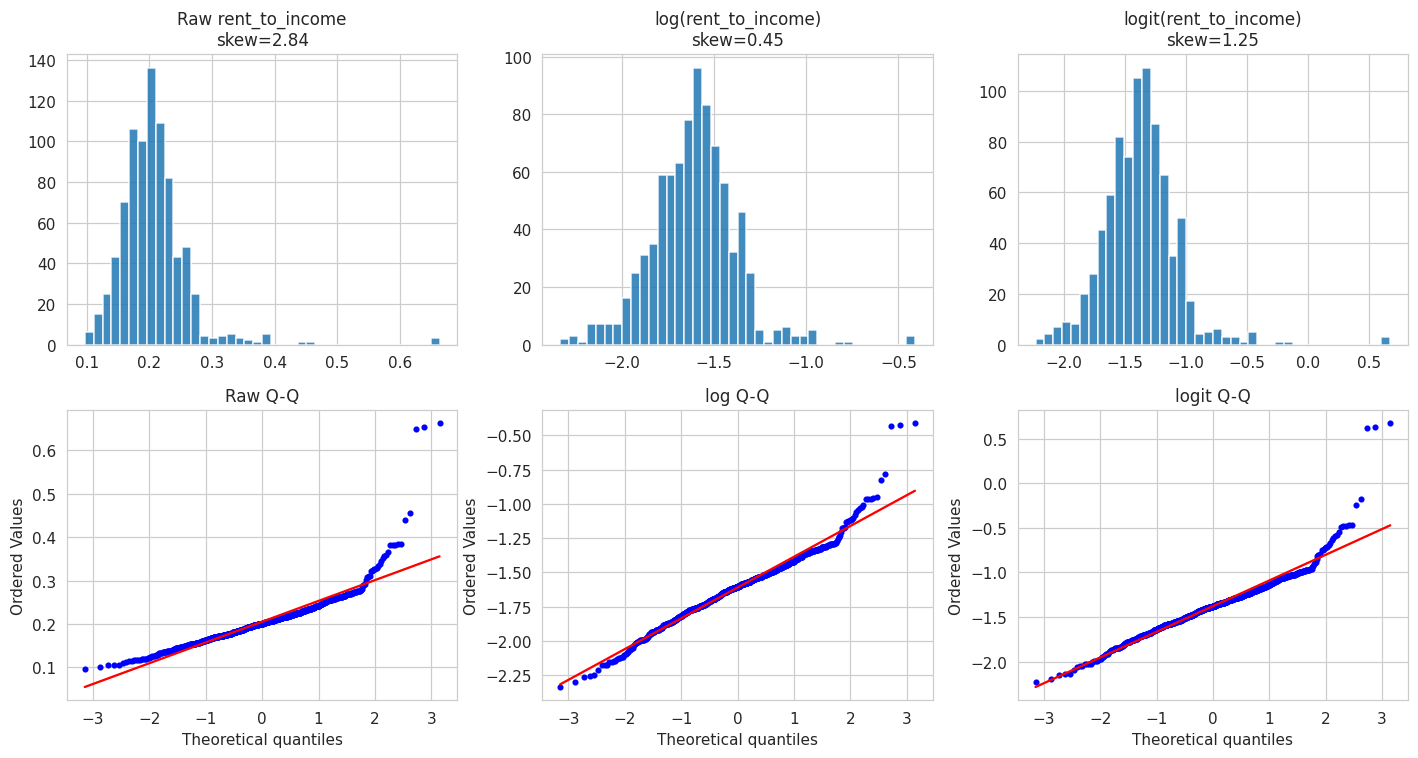

  raw   : Shapiro W=0.8764, skew=2.840, kurtosis=19.628
  log   : Shapiro W=0.9765, skew=0.448, kurtosis=2.862
  logit : Shapiro W=0.9513, skew=1.247, kurtosis=7.496


In [ ]:
y = df['rent_to_income']
y_log = np.log(y)
y_logit = np.log(y / (1 - y))

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, series, title in zip(
    axes[0],
    [y, y_log, y_logit],
    ['Raw rent_to_income', 'log(rent_to_income)', 'logit(rent_to_income)']
):
    ax.hist(series, bins=40, edgecolor='white', alpha=0.85)
    skew = stats.skew(series)
    ax.set_title(f'{title}\nskew={skew:.2f}')

for ax, series, title in zip(
    axes[1],
    [y, y_log, y_logit],
    ['Raw Q-Q', 'log Q-Q', 'logit Q-Q']
):
    stats.probplot(series, dist='norm', plot=ax)
    ax.set_title(title)
    ax.get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()

# Shapiro-Wilk normality
from scipy.stats import shapiro
for name, s in [('raw', y), ('log', y_log), ('logit', y_logit)]:
    stat, p = shapiro(s.sample(500, random_state=0))  
    print(f'  {name:6s}: Shapiro W={stat:.4f}, skew={stats.skew(s):.3f}, kurtosis={stats.kurtosis(s):.3f}')

After log transform, the distribution of raw data becomes approximately normal with low skewness and kurtosis.  We will use log-transformed data in our following model training.

### A.4 Univariate distributions of all predictors

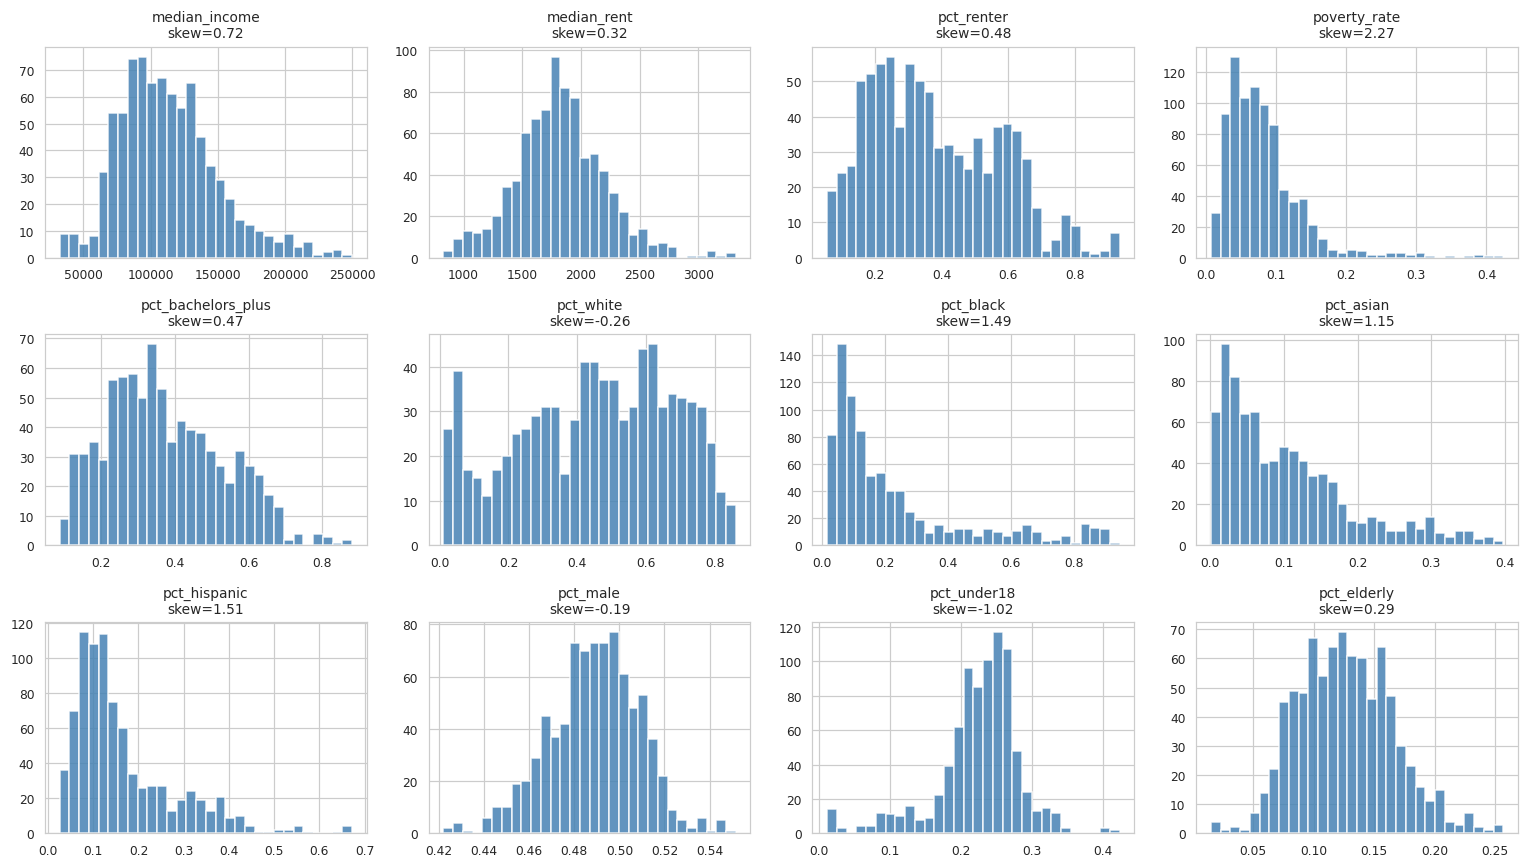

In [ ]:
predictors = [
    'median_income', 'median_rent', 'pct_renter', 'poverty_rate', 'pct_bachelors_plus',
    'pct_white', 'pct_black', 'pct_asian', 'pct_hispanic',
    'pct_male', 'pct_under18', 'pct_elderly'
]

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for ax, var in zip(axes.flat, predictors):
    ax.hist(df[var], bins=30, edgecolor='white', alpha=0.85, color='steelblue')
    sk = stats.skew(df[var])
    ax.set_title(f'{var}\nskew={sk:.2f}', fontsize=9)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()  

### A.5 Correlation analysis: Pearson + Spearman

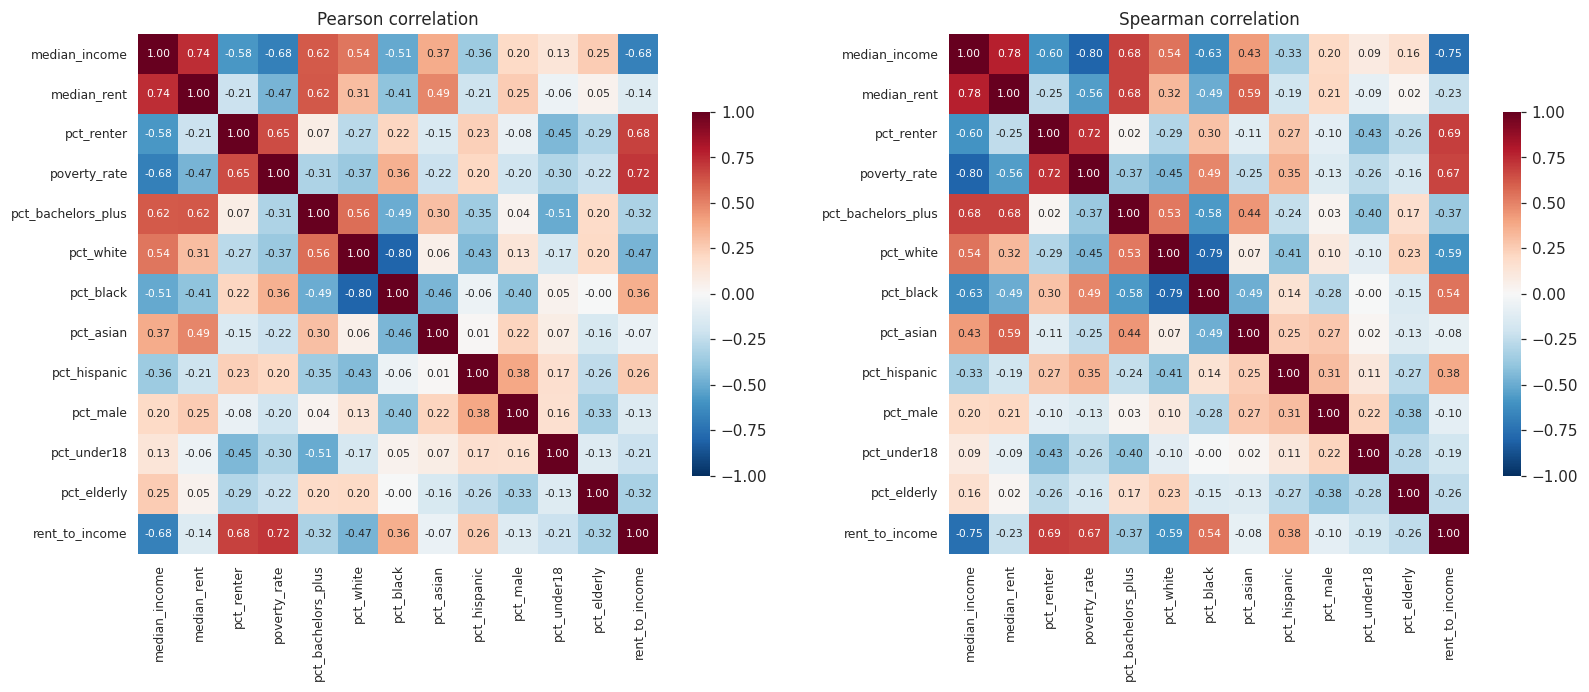

In [ ]:
# Check linear and nonlinear relationships with target
cols = predictors + ['rent_to_income']
pearson = df[cols].corr(method='pearson')
spearman = df[cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, mat, name in zip(axes, [pearson, spearman], ['Pearson', 'Spearman']):
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, ax=ax,
                annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
    ax.set_title(f'{name} correlation')
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [8]:
# Pearson vs Spearman delta — large gap = nonlinear relationship
delta = (spearman - pearson).abs()
y_delta = delta['rent_to_income'].drop('rent_to_income').sort_values(ascending=False)
print('Top |Spearman - Pearson| with target (suggests non-linearity):')
print(y_delta.round(3).to_string())

Top |Spearman - Pearson| with target (suggests non-linearity):
pct_black             0.178
pct_white             0.129
pct_hispanic          0.123
median_rent           0.093
median_income         0.078
pct_elderly           0.068
pct_bachelors_plus    0.053
poverty_rate          0.041
pct_male              0.031
pct_under18           0.018
pct_asian             0.016
pct_renter            0.013


**Interpretation**: predictors with large |Spearman − Pearson| relative to target are strong candidates for non-linear transforms

### A.5 Multicollinearity: systematic VIF

In [32]:
def compute_vif(X):
    Xc = sm.add_constant(X)
    rows = []
    for i, col in enumerate(Xc.columns):
        if col == 'const':
            continue
        rows.append({'variable': col, 'VIF': variance_inflation_factor(Xc.values, i)})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False).reset_index(drop=True)

# Include everything except pct_female 
X_all = df[[
    'median_income','median_rent','pct_renter','poverty_rate','pct_bachelors_plus',
    'pct_white','pct_black','pct_asian','pct_hispanic',
    'pct_male','pct_under18','pct_elderly'
]].copy()

vif0 = compute_vif(X_all)
print('VIF — all predictors (pct_female dropped):')
print(vif0.to_string(index=False))


VIF — all predictors (pct_female dropped):
          variable        VIF
         pct_black 362.464840
         pct_white 355.297706
      pct_hispanic  83.327788
         pct_asian  54.491127
     median_income   8.601250
pct_bachelors_plus   6.970142
        pct_renter   4.211972
       median_rent   3.445768
       pct_under18   2.864017
      poverty_rate   2.657130
          pct_male   1.794206
       pct_elderly   1.534936


In [31]:
# Iterative pruning: drop variable with highest VIF until all < 10
X_prune = X_all.copy()
drop_log = []
while True:
    v = compute_vif(X_prune)
    worst = v.iloc[0]
    if worst['VIF'] < 10:
        break
    drop_log.append((worst['variable'], round(worst['VIF'], 2)))
    X_prune = X_prune.drop(columns=[worst['variable']])

print('Iterative drop:', drop_log)

Iterative drop: [('pct_black', np.float64(362.46))]


### A.6 Panel structure: within vs between variance

In [25]:
def variance_decomp(df, var, group='zip'):
    grand_mean = df[var].mean()
    group_means = df.groupby(group)[var].mean()
    n_per_group = df.groupby(group).size()

    between = ((group_means - grand_mean) ** 2 * n_per_group).sum() / len(df)
    within = df.groupby(group)[var].var(ddof=0).mean()
    total = df[var].var(ddof=0)
    return {
        'total_var': total,
        'between_var': between,
        'within_var': within,
        'between_pct': between / total,
        'within_pct': within / total,
    }

rows = []
for var in ['rent_to_income','poverty_rate',
            'pct_renter','pct_bachelors_plus', 'pct_white','pct_black','pct_asian','pct_hispanic',]:
    d = variance_decomp(df, var)
    rows.append({'variable': var, 'between_%': f"{d['between_pct']:.1%}",
                 'within_%': f"{d['within_pct']:.1%}"})
decomp = pd.DataFrame(rows)
print('Variance decomposition:')
print(decomp.to_string(index=False))

Variance decomposition:
          variable between_% within_%
    rent_to_income     95.5%     4.5%
      poverty_rate     96.9%     3.1%
        pct_renter     99.3%     0.7%
pct_bachelors_plus     98.7%     1.3%
         pct_white     99.4%     0.6%
         pct_black     99.7%     0.3%
         pct_asian     98.1%     1.9%
      pct_hispanic     98.7%     1.3%


### A.7 Time dynamics by zipcode

In [24]:
panel = df.sort_values(['zip','year']).copy()
panel['rti_lag'] = panel.groupby('zip')['rent_to_income'].shift(1)
valid = panel.dropna(subset=['rti_lag'])
lag1_corr = valid[['rent_to_income','rti_lag']].corr().iloc[0,1]
print(f'Within-ZIP lag-1 autocorrelation of rent_to_income: {lag1_corr:.3f}')


Within-ZIP lag-1 autocorrelation of rent_to_income: 0.974


### A.8 Outlier & leverage diagnostics (baseline OLS)

Fit a quick OLS to flag high-leverage points and outliers. These ZIPs warrant case-by-case scrutiny in the final report.

In [29]:
# Use VIF-pruned predictor set
X_diag = X_prune.copy()
X_diag_const = sm.add_constant(X_diag)
ols_diag = sm.OLS(df['rent_to_income'], X_diag_const).fit()
infl = OLSInfluence(ols_diag)

leverage = infl.hat_matrix_diag
studentized = infl.resid_studentized_internal
cooks = infl.cooks_distance[0]

# Top 10 most influential ZIP-years
infl_df = df[['zip','year','rent_to_income']].copy()
infl_df['leverage'] = leverage
infl_df['stud_resid'] = studentized
infl_df["cooks_d"] = cooks
top_infl = infl_df.sort_values('cooks_d', ascending=False).head(10)
print('Top 10 most influential observations:')
print(top_infl.round(4).to_string(index=False))

Top 10 most influential observations:
  zip  year  rent_to_income  leverage  stud_resid  cooks_d
20006  2020          0.6501    0.1246     10.3235   1.2638
20006  2022          0.6630    0.0767     12.5825   1.0954
20006  2021          0.6538    0.0724     12.8285   1.0702
20015  2022          0.0968    0.0554      3.1873   0.0496
22060  2019          0.3842    0.0972      1.6220   0.0236
20710  2019          0.3560    0.0228      3.1987   0.0199
20710  2018          0.3594    0.0210      3.0475   0.0166
22060  2018          0.3854    0.0875      1.4315   0.0164
22205  2022          0.1044    0.0290      2.5509   0.0162
20015  2021          0.1052    0.0336      2.3398   0.0158


**Findings**: zipcode 20006 has greater than 1 cook's D for three years so we will dump it for model training. 